<a href="https://colab.research.google.com/github/aminta-bt/Gen-AI-Challenge/blob/main/Challenge_2_Aminta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Challenge 2: AI Fashion Designer**

**Theme:** Summer to Winter Wear (Blending a short T-shirt into a long coat).

Trained an Autoencoder to learn the shapes of clothing using the Fashion-MNIST dataset. Once it understood the shapes, I took a standard T-shirt and a heavy coat, and used the AI to mathematically blend them together step-by-step.

***Tools & Models Used:*** Python, TensorFlow, Keras (specifically a Dense Multi-Layer Perceptron autoencoder), and Matplotlib to visualize the latent vector interpolation.

This created a 5-piece fashion collection mood board that smoothly transitions from a short shirt to a long coat. It proves that it actually learned how to mix different clothing structures together to create new designs.

### **Fashion Designer Autoencoder**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist

# 1. Load and prepare the fashion dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# 2. Build the AI Fashion Designer
latent_dim = 64 # This is the "Latent Space" we will explore!

# The Encoder (Turns clothes into numbers)
encoder = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(256, activation='relu'),
    layers.Dense(latent_dim, activation='linear')
])

# The Decoder (Turns numbers back into clothes)
decoder = models.Sequential([
    layers.Dense(256, activation='relu', input_shape=(latent_dim,)),
    layers.Dense(28 * 28, activation='sigmoid'),
    layers.Reshape((28, 28))
])

# The Full Model
autoencoder = models.Sequential([encoder, decoder])
autoencoder.compile(optimizer='adam', loss='mse')

# 3. Train the model fast (just 5 epochs)
print("Training the Fashion AI... (~1 minute)")
autoencoder.fit(x_train, x_train, epochs=5, batch_size=256, validation_data=(x_test, x_test))

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training the Fashion AI... (~1 minute)
Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 0.0363 - val_loss: 0.0191
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0168 - val_loss: 0.0148
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.0137 - val_loss: 0.0131
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0123 - val_loss: 0.0150
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 0.0115 - val_loss: 0.0110


### **Exploring the Latent Space**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


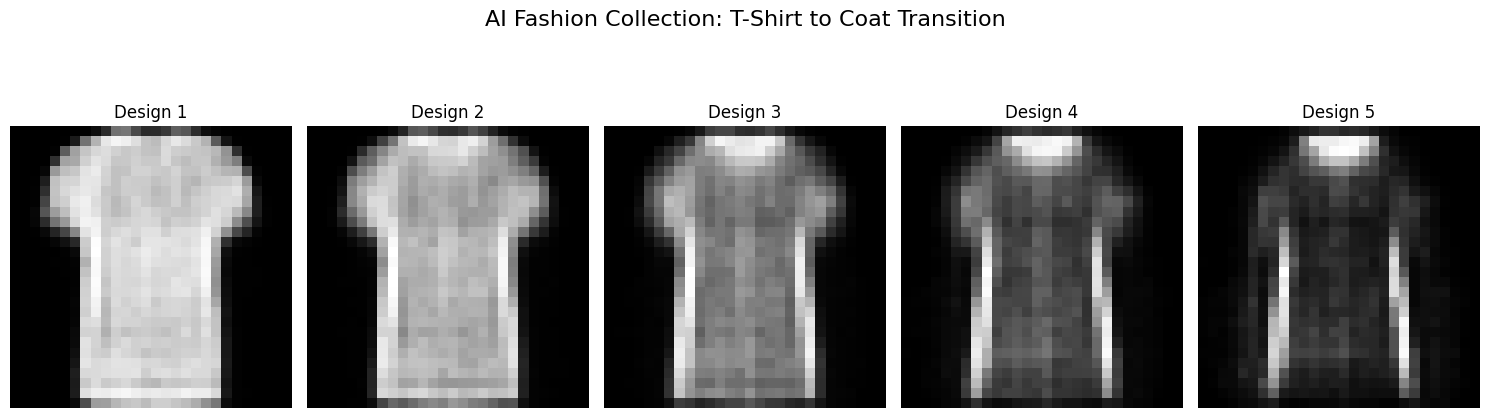

In [ ]:
# 1. Find two specific items to act as the "Ends" of our collection
# Let's blend a T-shirt (Class 0) into a Coat (Class 4) to make a cohesive line
tshirt_idx = np.where(y_test == 0)[0][0]
coat_idx = np.where(y_test == 4)[0][0]

item_A = x_test[tshirt_idx]
item_B = x_test[coat_idx]

# 2. Get their "Latent Vectors" (Sampling)
latent_A = encoder.predict(item_A[np.newaxis, ...])[0]
latent_B = encoder.predict(item_B[np.newaxis, ...])[0]

# 3. Interpolation (Creating the designs between them)
num_designs = 5
collection = []

for i in range(num_designs):
    # Vector arithmetic: smoothly shift from item_A to item_B
    ratio = i / (num_designs - 1)
    new_latent = (1.0 - ratio) * latent_A + (ratio) * latent_B

    # Decode the new vector into a generated design
    generated_design = decoder.predict(new_latent[np.newaxis, ...])[0]
    collection.append(generated_design)

# 4. Generate the Final Mood Board
plt.figure(figsize=(15, 5))
plt.suptitle("AI Fashion Collection: T-Shirt to Coat Transition", fontsize=16)

for i in range(num_designs):
    plt.subplot(1, num_designs, i + 1)
    plt.imshow(collection[i], cmap='gray')
    plt.title(f"Design {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()